In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("pnkjgpt/butterfly-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 426M/426M [00:20<00:00, 21.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4):
['Train']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the path to the main training directory
train_dir = os.path.join(path, 'Train')

# FIX: Use '/content/' instead of 'base_path' (which was /kaggle/input)
# '/content/' is writable in Google Colab
split_base_dir = '/content/split_dataset'

# Create new train and test directories
new_train_dir = os.path.join(split_base_dir, 'train')
new_test_dir = os.path.join(split_base_dir, 'test')

os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

print(f"Original training data directory: {train_dir}")
print(f"New training data will be stored in: {new_train_dir}")
print(f"New testing data will be stored in: {new_test_dir}")

# List all subdirectories (classes) in the original train_dir
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    # Split images into train (80%) and test (20%)
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

    # Create class specific directories in new train/test folders
    os.makedirs(os.path.join(new_train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(new_test_dir, class_name), exist_ok=True)

    # Copy training images to the new train directory
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(new_train_dir, class_name, os.path.basename(img_path)))

    # Copy testing images to the new test directory
    for img_path in test_images:
        shutil.copy(img_path, os.path.join(new_test_dir, class_name, os.path.basename(img_path)))

    print(f"Processed Class '{class_name}'")

print("Dataset split into training and testing sets successfully in /content/!")

Original training data directory: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4/Train
New training data will be stored in: /content/split_dataset/train
New testing data will be stored in: /content/split_dataset/test
Processed Class 'julia'
Processed Class 'large marble'
Processed Class 'orange tip'
Processed Class 'indra swallow'
Processed Class 'clouded sulphur'
Processed Class 'clodius parnassian'
Processed Class 'ulyses'
Processed Class 'southern dogface'
Processed Class 'adonis'
Processed Class 'orchard swallow'
Processed Class 'skipper'
Processed Class 'red spotted purple'
Processed Class 'peacock'
Processed Class 'red admiral'
Processed Class 'yellow swallow tail'
Processed Class 'an 88'
Processed Class 'black hairstreak'
Processed Class 'malachite'
Processed Class 'paper kite'
Processed Class 'eastern coma'
Processed Class 'beckers white'
Processed Class 'mangrove skipper'
Processed Class 'zebra long wing'
Processed Class 'sixspot burnet'
Pr

In [ ]:
# Verify the structure and counts
print(f"Contents of {new_train_dir}:")
for class_name in os.listdir(new_train_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_train_dir, class_name)))} images")

print(f"Contents of {new_test_dir}:")
for class_name in os.listdir(new_test_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_test_dir, class_name)))} images")


Contents of /content/split_dataset/train:
  julia: 83 images
  large marble: 57 images
  orange tip: 64 images
  indra swallow: 83 images
  clouded sulphur: 68 images
  clodius parnassian: 56 images
  ulyses: 52 images
  southern dogface: 68 images
  adonis: 69 images
  orchard swallow: 58 images
  skipper: 98 images
  red spotted purple: 68 images
  peacock: 70 images
  red admiral: 65 images
  yellow swallow tail: 77 images
  an 88: 66 images
  black hairstreak: 64 images
  malachite: 75 images
  paper kite: 66 images
  eastern coma: 69 images
  beckers white: 84 images
  mangrove skipper: 64 images
  zebra long wing: 78 images
  sixspot burnet: 72 images
  silver spot skipper: 68 images
  grey hairstreak: 71 images
  copper tail: 96 images
  crimson patch: 74 images
  metalmark: 78 images
  question mark: 79 images
  chestnut: 64 images
  morning cloak: 64 images
  straited queen: 69 images
  gold banded: 75 images
  scarce swallow: 100 images
  sootywing: 92 images
  banded peacock

## GPU Check

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {gpus}")
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Training will run on CPU.")

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


## Build and Train MobileNet Model

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224) # MobileNetV2 expects 224x224 input
BATCH_SIZE = 32
EPOCHS = 10

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    new_train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    new_test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Get the number of classes
num_classes = train_generator.num_classes

# Load pre-trained MobileNetV2 model, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x) # Add a dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Final classification layer

# Construct the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

Found 3562 images belonging to 50 classes.
Found 917 images belonging to 50 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,620,978 (13.81 MB)

 Trainable params: 1,362,994 (5.20 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 110s 799ms/step - accuracy: 0.3855 - loss: 2.8481 - val_accuracy: 0.6292 - val_loss: 1.9240
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 62s 550ms/step - accuracy: 0.7600 - loss: 1.2790 - val_accuracy: 0.7415 - val_loss: 1.1462
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 541ms/step - accuracy: 0.8487 - loss: 0.7726 - val_accuracy: 0.8004 - val_loss: 0.8852
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 60s 539ms/step - accuracy: 0.8773 - loss: 0.5626 - val_accuracy: 0.8070 - val_loss: 0.7685
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 523ms/step - accuracy: 0.9051 - loss: 0.4480 - val_accuracy: 0.8135 - val_loss: 0.6964
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 545ms/step - accuracy: 0.9236 - loss: 0.3652 - val_accuracy: 0.8332 - val_loss: 0.6446
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 527ms/step - accuracy: 0.9340 - loss: 0.3134 - val_accuracy: 0.8364 - val_loss: 0.6173
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 528ms/step - accuracy: 0.9424 - loss: 

## Training Results Summary

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Print final training and validation accuracy/loss from history
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.8451 - loss: 0.5515

Test Loss: 0.5515
Test Accuracy: 0.8451

Final Training Accuracy: 0.9579
Final Validation Accuracy: 0.8451
Final Training Loss: 0.2121
Final Validation Loss: 0.5515


## Training History Plot

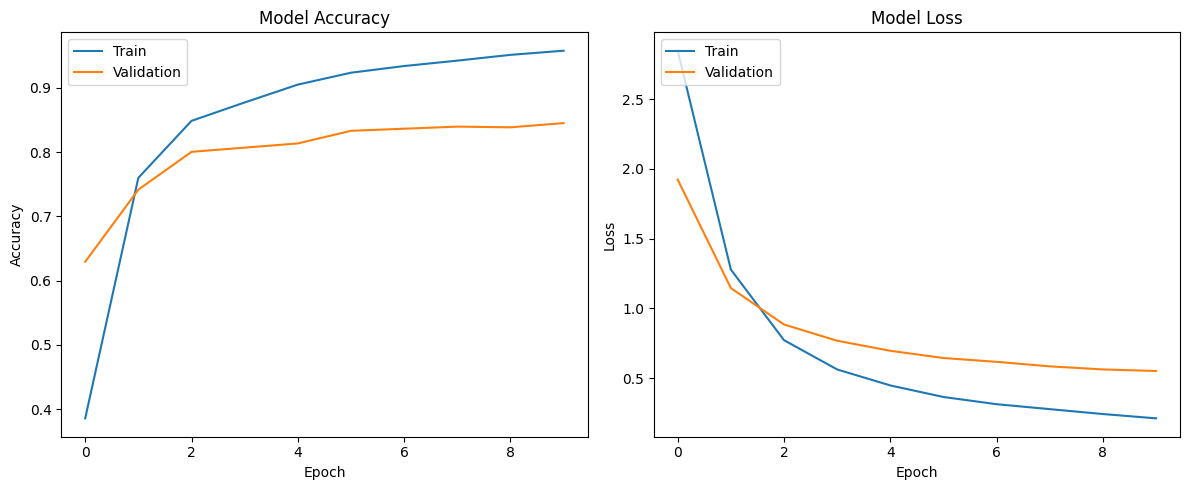

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()